In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir(r'C:\\Users\\nokni\\work\\MHDTurbPy\\')
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs
from functions import  three_D_funcs

sys.path.insert(1, os.path.join(os.getcwd(), 'functions', '3d_anis_analysis_toolbox'))
sys.path.insert(1, os.path.join(os.getcwd(), 'functions', 'modwt_5pt_style'))
import collect_wave_coeffs
import data_analysis
import polarization_analysis
import pandas as pd
import matplotlib.pyplot as plt


sys.path.insert(1, os.path.join(os.getcwd(), 'functions','3d_anis_analysis_toolbox'))
import collect_wave_coeffs 
import data_analysis 


# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt


06-Mar-26 09:50:50: Loaded SOLO.py (2026-02-22-v7.2-ola-fft-cap-auto)


In [5]:
import numpy as np
from pathlib import Path
from joblib import Parallel, delayed

import general_functions as func
import data_analysis


# Choose SC

dt_step = 0.25
sc = 'WIND'
lp = f'C:\\Users\\nokni\\work\\WIND_3D\\data\\3_sec\\{sc}\\'
interval_type = 'fast_alfvenic'  # Options: ['slow_non_alfvenic', 'slow_alfvenic', 'fast_alfvenic']
selection_conditions = {
    'd_min': 0,
    'd_max': 1.1,
    'sigma_c_min': 0,
    'sigma_c_max': 1,
    'part_max_frac_mis': 0.75,
    'mag_max_frac_mis': 0.75,
}
use_local_polarity = False
extra_conditions = True
overwrite_existing_files = True
estimate_alignment_angle = True
return_B_in_vel_units    =  True

Estimate_5points = [True]
return_flucs     = True
strict_threshs   = [False]
only_general     = 1

thetas_phis_step = 5
consider_Vsc = False
three_sec_resol = False
n_jobs          = 10


ts_list = [
    "dV", "dzp", "dzm", 'phis', 'thetas', 'Vsw', 'Bmod', 'VBangle_big', 'sign_Bx', 'kinet_normal',
    'sig_c', 'sig_r', 'sins_zpm_num', 'sins_zpm_den', 'compress_simple', 'compress_simple_V', 'local_polarity',
    'l_ell', 'l_lambda', 'l_xi', 'db_perp_amp_nT',
]


# Define the time lags in seconds
max_hours = 300
keep_wave_coeefs = False
return_mag_align_correl = False

if extra_conditions:
    estimate_alignment_angle = True
    return_mag_align_correl = True

only_E1 = False
alfvenic_intervals = True
duration = 8
step = 2
qorder = np.arange(1, 13)
base_path = Path('/Users/nokni/work/3d_anisotropy/radial_evolution/data')


credentials = {
    'psp': {
        'fields': {'username': 'mvelli', 'password': 'flds@psp'},
        'sweap': {'username': 'mvelli', 'password': '2019swe@pd@ta'},
    }
}


fnames = func.load_files(lp, 'final.pkl')

for strict_thresh in strict_threshs:
    if only_general:
        theta_thresh_gen = 0
        phi_thresh_gen = 0
    else:
        theta_thresh_gen = None
        phi_thresh_gen = None

    if strict_thresh:
        conditions = {
            'ell_perp': {'theta': 85, 'phi': 85},
            'Ell_perp': {'theta': 85, 'phi': 5},
            'ell_par': {'theta': 5, 'phi': 90},
            'ell_par_rest': {'theta': 5, 'phi': 5},
        }
    else:
        conditions = {
            'ell_perp': {'theta': 80, 'phi': 80},
            'Ell_perp': {'theta': 80, 'phi': 10},
            'ell_par': {'theta': 10, 'phi': 90},
            'ell_par_rest': {'theta': 10, 'phi': 10},
        }

    if sc == 'WIND':
        consider_Vsc = False

    for Estimate_5point in Estimate_5points:
        results = Parallel(n_jobs=n_jobs)(
            delayed(data_analysis.modwt_two_pt_wavelet_analysis)(
                i,
                fnames,
                credentials,
                conditions,
                return_flucs,
                consider_Vsc,
                Estimate_5point,
                keep_wave_coeefs,
                strict_thresh,
                max_hours,
                qorder,
                estimate_alignment_angle,
                return_mag_align_correl,
                only_general,
                phi_thresh_gen,
                theta_thresh_gen,
                sc=sc,
                extra_conditions=extra_conditions,
                ts_list=ts_list,
                overwrite_existing_files=overwrite_existing_files,
                thetas_phis_step=thetas_phis_step,
                return_B_in_vel_units=return_B_in_vel_units,
                dt_step                  = dt_step,
                use_local_polarity       = use_local_polarity
            )
            for i in range(len(fnames))
        )


C:\Users\nokni\work\WIND_3D\data\3_sec\WIND\*\final.pkl


In [6]:
a

NameError: name 'a' is not defined

In [1]:
lp     = f'C:\\Users\\nokni\\work\\WIND_3D\\data\\3_sec\\{sc}\\'
fnames = func.load_files(lp, 'general_SF_5pt_extra_conditions_theta_0_phi_0.pkl', 'final_vs8')
df     = pd.read_pickle(fnames[4])

NameError: name 'sc' is not defined

In [11]:
df['flucts'].keys()

dict_keys(['ell_all', 'turb_amp', 'tau_lags', 'l_di', 'Vsw', 'di', 'dt', 'B_flag'])

In [15]:
df['flucts']['ell_all'].keys()

Index(['R', 'T', 'N', 'dV_R', 'dV_T', 'dV_N', 'zp_R', 'zp_T', 'zp_N', 'zm_R',
       'zm_T', 'zm_N', 'db_perp_amp', 'l_lambda', 'l_xi', 'kinet_normal',
       'phis', 'thetas', 'Vsw', 'Bmod', 'VBangle_big', 'sig_c', 'sig_r',
       'compress_simple', 'compress_simple_V', 'lambda'],
      dtype='object')

In [11]:
x, y = np.hstack(df['flucts']['Ell_perp']['xis']), np.hstack(df['flucts']['Ell_perp']['R']**2)

TypeError: unsupported operand type(s) for ** or pow(): 'list' and 'int'

In [33]:
sm = func.binned_quantity(x,y, bins=20)

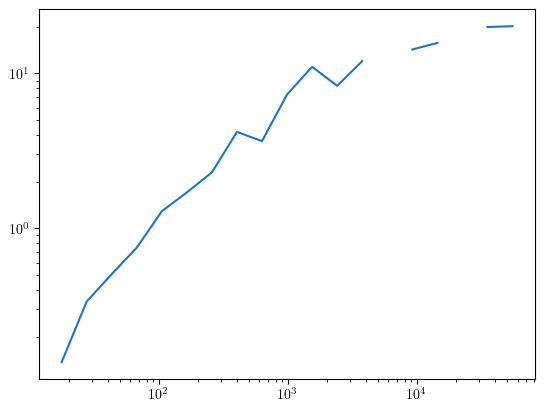

In [34]:
plt.loglog(sm[0], sm[1])

In [ ]:
x, y = np.hstack(df['flucts']['Ell_perp']['xis']), np.hstack(df['flucts']['Ell_perp']['R']**2)